In [12]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import time
from typing import List


In [5]:
cwd = Path(os.getcwd())
print(cwd)

json_path = cwd / 'WS2_Grating_Eamonn' / 'Results' / 'WS₂, SiO₂, Si 5.2 (alpha 0.00)' / 'summary_v2.json'

with open(json_path, 'r') as summary:
    data = json.load(summary)
    # print(data)

C:\Users\whamp\PycharmProjects\research_project


In [14]:
# aim is to plot the mode energies and separation against: period, thickness, filling
import time

df = pd.DataFrame(columns=['period', 'thickness', 'filling', 'mean_energy', 'diff_energy'])

count_length_not_2 = 0
count_not_correct_form = 0
count_correct_form = 0
count_correct_vertices = 0
total = 0

# print(data)

# Extract data
for key, value in data.items():
    print(value)
    total += 1
    #print(value)
    # Extract thickness (t) and period (Λ) from the key string
    key_parts = key.split()
    thickness = float(key_parts[0].split('=')[1].replace('nm', ''))
    period = float(key_parts[1].split('=')[1].replace('nm', ''))
    ff = float(key_parts[2].split('=')[1].replace('nm', ''))
    
    keys = list(value['fitting info'].keys())

    if len(keys) < 2:
        count_length_not_2 += 1
        continue
    
   

    temp_vertices: list = []
    
    # Only consider entries with R2 > 0.6
    for i,key1 in enumerate(keys):
        R2 = value['fitting info'][key1]['R2']
        if (abs(R2) > 0.6) and (abs(R2) != 1.0):
            # Extract vertex value from fitting results
            vertex = value['fitting results']['vertices'][i]
            
            # Append data to lists
            temp_vertices.append([key1,vertex])
            #print([key1,vertex])
            
    if len(temp_vertices) == 2:
        
        # select where 1st vertex value less than second
        # print(key)
        # print(value)
        count_correct_vertices += 1
        
        vertices = [temp_vertices[0][1], temp_vertices[1][1]]
        forms = [temp_vertices[0][0], temp_vertices[1][0]]
        forms: List[int] = [int(n) for n in forms]
        
        # for vertices of form 0: 1.5, 1: 1.1, should register as correct form
        if vertices[0] > vertices[1]:
            if forms[0]%2 < forms[1]%2: # 1st odd (%2=0) 2nd even (%2=1)
                count_correct_form += 1
        
        elif vertices[0] < vertices[1]:
            if forms[0]%2 > forms[1]%2: # change inequality sign
                count_correct_form += 1

        else:
            count_not_correct_form += 1
            continue
        
        print(f"Modes detected of correct form:")
        print(*temp_vertices)
        # time.sleep(5)

        mean_energy_value = np.mean(vertices)
        diff_energy_value = vertices[1] - vertices[0]
            
        new_row = {
            'period': period,
            'thickness': thickness,
            'filling': ff,
            'mean_energy': mean_energy_value,
            'diff_energy': diff_energy_value
        }
        
        # Append the new row to the DataFrame
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
            
    else:
        count_length_not_2 += 1
        continue

df.head()
df.info()

{'fitting info': {'0': {'R2': 0.9682853501858086, 'popt': [0.033054260942010465, 6937.8759138223995, 9.999436403838796, 2710.6789769226766, 5.820938446072464, 4.756891385696185, 0.0022244975154490807]}, '1': {'R2': 0.9543260568501774, 'popt': [-0.20027101876661277, 6970.801036221456, 0.9350110162167585, 756.971414138008, 0.5870217126691236, 2.6646575892950115, 0.9999934317875891]}}, 'fitting results': {'vertices': [1.5441896637683143, 1.2813982721903496], 'asyms': [-0.0406885954498346, 1.1394560058232857]}}
Modes detected of correct form:
['0', 1.5441896637683143] ['1', 1.2813982721903496]
{'fitting info': {'1': {'R2': 0.6684693633634818, 'popt': [-0.0965531795937918, 7374.115026534569, 9.999778649859818, 9999.997222462018, 94.97898043652316, 4.311880837756651, 0.004466275919548975]}}, 'fitting results': {'vertices': [1.6645933261774881], 'asyms': [0.002038814894528292]}}
{'fitting info': {}, 'fitting results': {'vertices': [], 'asyms': []}}
{'fitting info': {}, 'fitting results': {'ve

C:\Users\whamp\AppData\Local\Temp\ipykernel_27736\2653642170.py:86: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


In [15]:
counts = pd.Series([count_length_not_2, count_not_correct_form, count_correct_form, count_correct_vertices, total], index=['len not 2', 'not correct form', 'correct form', 'correct vertices (len 2)', 'total'])
counts

len not 2                    8
not correct form             0
correct form                26
correct vertices (len 2)    26
total                       34
dtype: int64

In [16]:


periods = df['period'].to_numpy()
thicknesses = df['thickness'].to_numpy()
filling = df['filling'].to_numpy()
diff_energy = df['diff_energy'].to_numpy()
mean_energy = df['mean_energy'].to_numpy()

# 
# df.head(5)
# df.info()

df_path = json_path.parents[0] / 'summary_v2.csv'
df.to_csv(df_path)


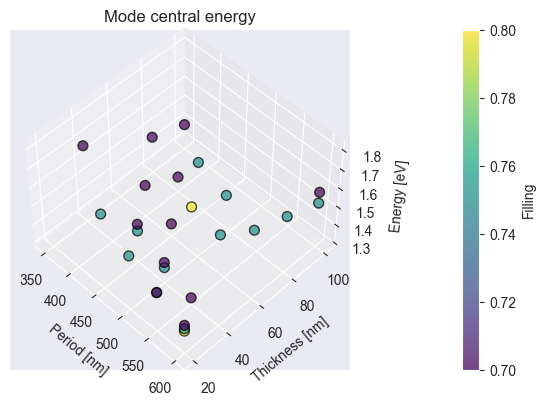

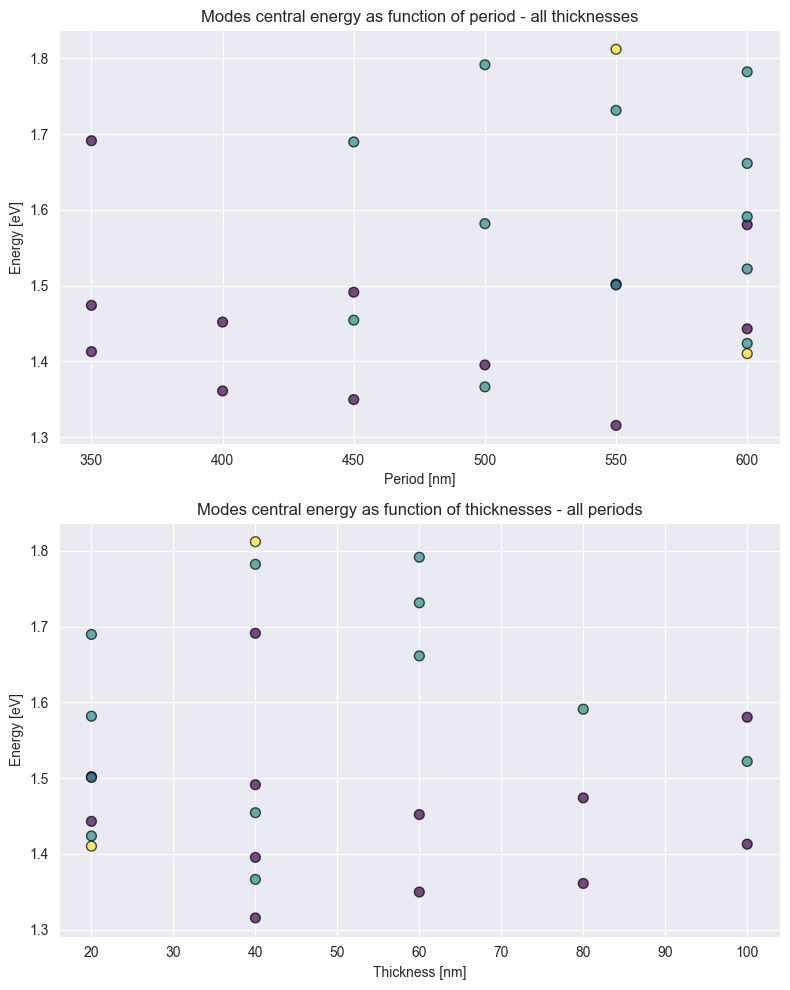

In [17]:
title = 'Mode central energy'

# Create a figure with 2 rows and 1 column for the 3D plot above and 2D plots below
fig = plt.figure(figsize=(12, 15))

p_lab='Period [nm]'
t_lab='Thickness [nm]'
e_lab='Energy [eV]'
f_lab = 'Filling'

# 3D Plot
ax1 = fig.add_subplot(311, projection='3d')
scatter1 = ax1.scatter(periods, thicknesses, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
cbar = fig.colorbar(scatter1)
cbar.set_label(f_lab)
ax1.set_xlabel(p_lab)
ax1.set_ylabel(t_lab)
ax1.set_zlabel(e_lab)
ax1.set_title(title)
ax1.view_init(elev=50, azim=-45)
plt.subplots_adjust(right=2)
#ax1.invert_yaxis()
plt.show()

fig = plt.figure(figsize=(8, 10))
# 2D plot for Period vs Energy
ax2, ax3 = fig.subplots(nrows=2, ncols=1, sharex=False, sharey=False)

scatter2 = ax2.scatter(periods, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax2.set_xlabel(p_lab)
ax2.set_ylabel(e_lab)
ax2.set_title("Modes central energy as function of period - all thicknesses")

# 2D plot for Thickness vs Energy
scatter3 = ax3.scatter(thicknesses, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax3.set_xlabel(t_lab)
ax3.set_ylabel(e_lab)
ax3.set_title("Modes central energy as function of thicknesses - all periods")
# ax3.invert_xaxis()


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


<Figure size 1500x1000 with 0 Axes>

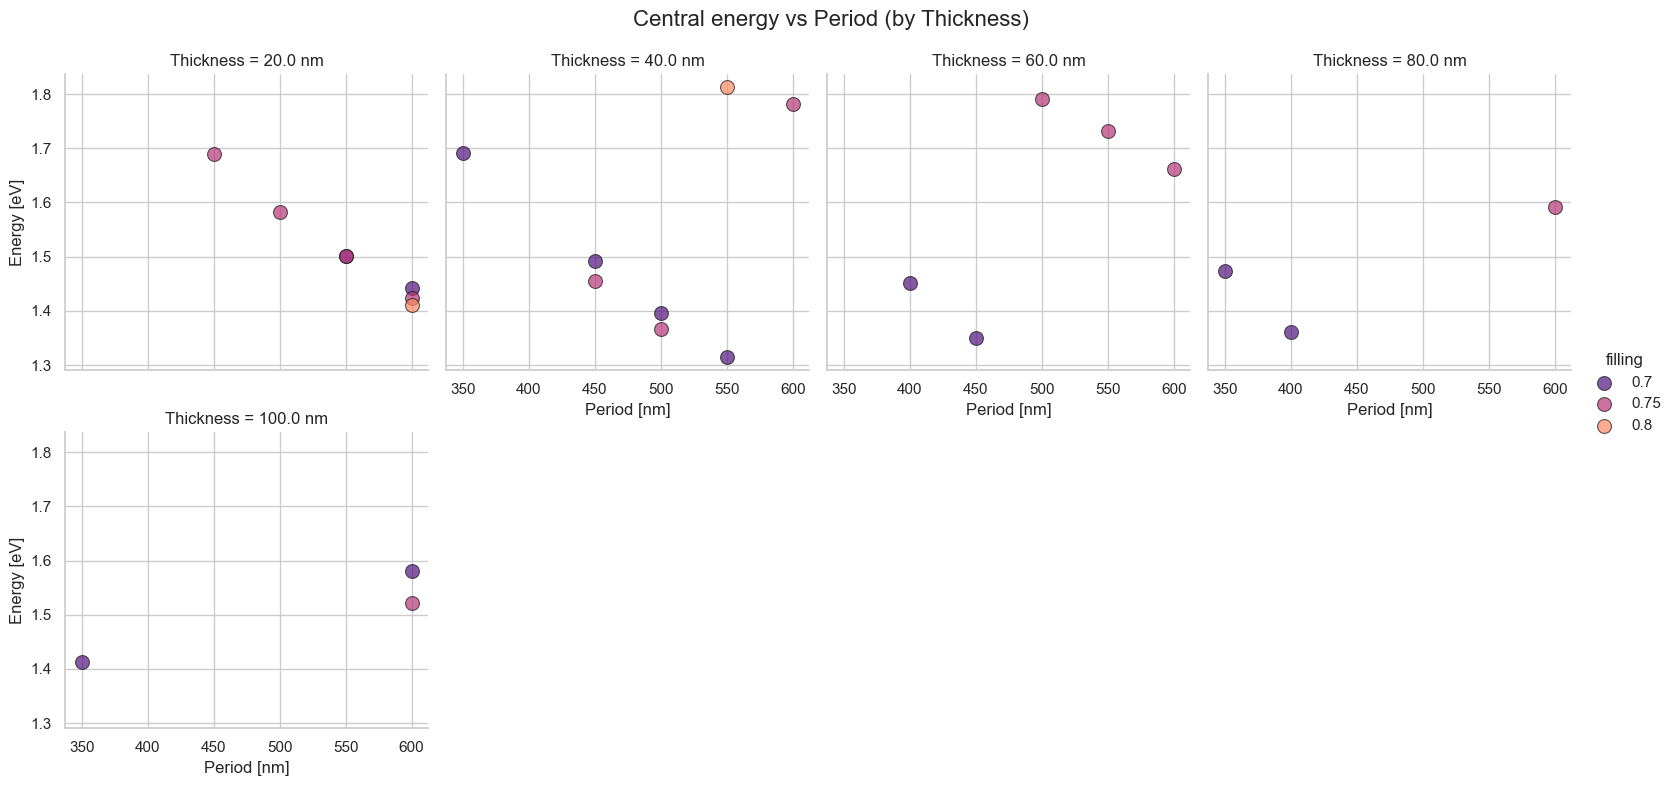

<Figure size 1500x1000 with 0 Axes>

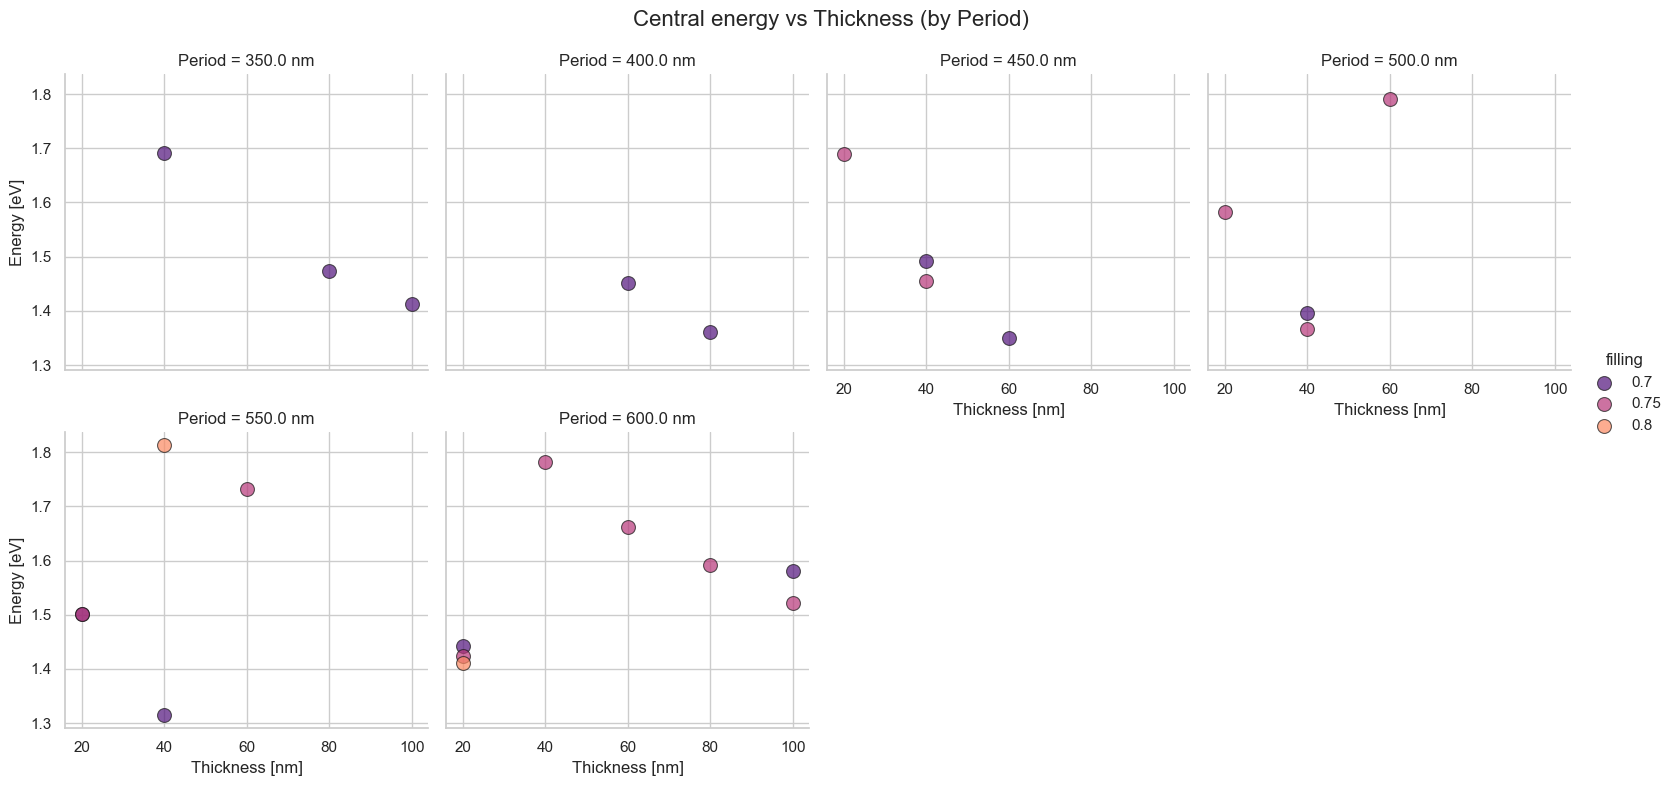

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the seaborn style
sns.set_theme(style="whitegrid")

# Create the figure for the 2D plots (Energy vs Period, with Thickness as separate plots)
fig1 = plt.figure(figsize=(15, 10))
g1 = sns.FacetGrid(
    data=df,
    col="thickness", 
    col_wrap=4, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g1.map_dataframe(
    sns.scatterplot, 
    x="period", 
    y="mean_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g1.set_axis_labels(p_lab, e_lab)
g1.set_titles(col_template="Thickness = {col_name} nm")
g1.add_legend()

# Display the Energy vs Period plot grid
plt.subplots_adjust(top=0.9)
g1.fig.suptitle('Central energy vs Period (by Thickness)', fontsize=16)
plt.show()

# Create the figure for the 2D plots (Energy vs Thickness, with Period as separate plots)
fig2 = plt.figure(figsize=(15, 10))
g2 = sns.FacetGrid(
    data=df,
    col="period", 
    col_wrap=4, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g2.map_dataframe(
    sns.scatterplot, 
    x="thickness", 
    y="mean_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g2.set_axis_labels(t_lab, e_lab)
g2.set_titles(col_template="Period = {col_name} nm")
g2.add_legend()

# Display the Energy vs Thickness plot grid
plt.subplots_adjust(top=0.9)
g2.fig.suptitle('Central energy vs Thickness (by Period)', fontsize=16)
plt.show()


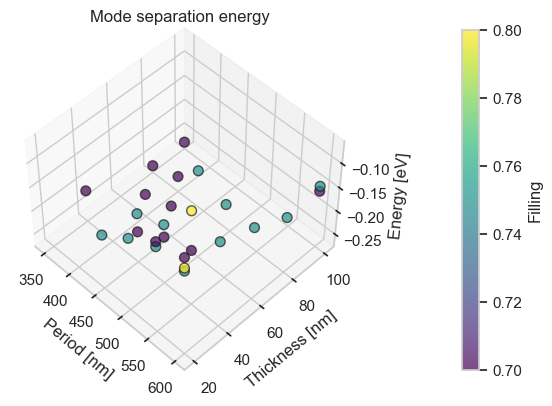

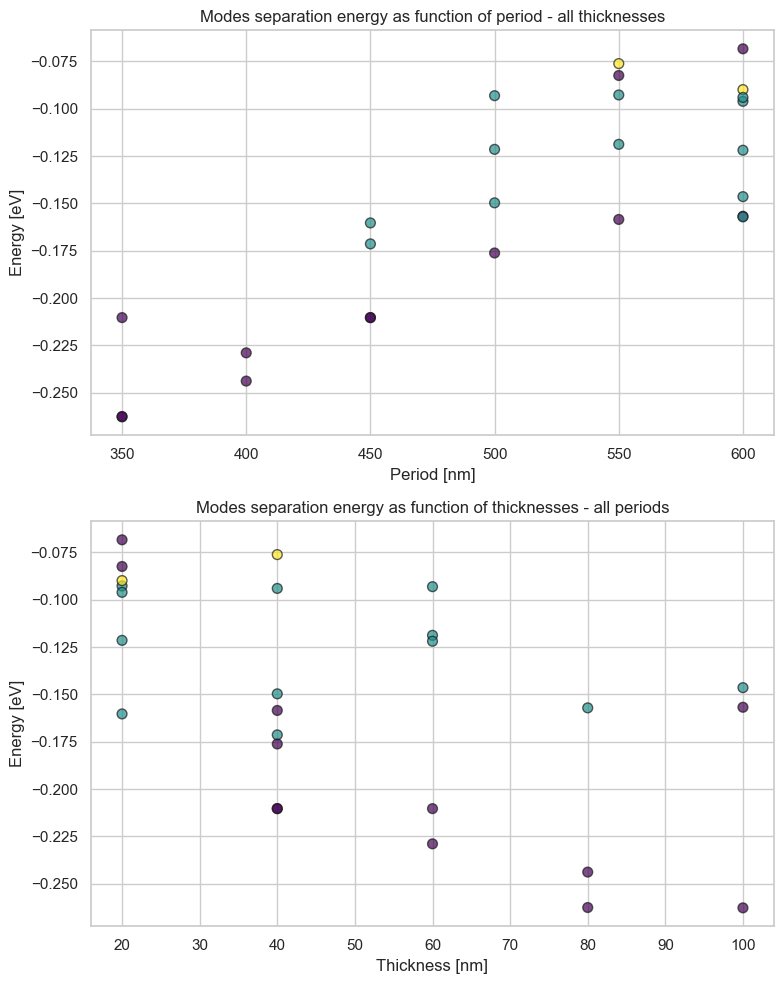

In [19]:

title = 'Mode separation energy'
#  = 'Modes central energy as function of thickness'


fig = plt.figure(figsize=(12, 15))

p_lab='Period [nm]'
t_lab='Thickness [nm]'
e_lab='Energy [eV]'
f_lab = 'Filling'

# 3D Plot
ax1 = fig.add_subplot(311, projection='3d')
scatter1 = ax1.scatter(periods, thicknesses, diff_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
cbar = fig.colorbar(scatter1)
cbar.set_label(f_lab)
ax1.set_xlabel(p_lab)
ax1.set_ylabel(t_lab)
ax1.set_zlabel(e_lab)
ax1.set_title(title)
ax1.view_init(elev=50, azim=-45)
plt.subplots_adjust(right=2)
#ax1.invert_yaxis()
plt.show()

fig = plt.figure(figsize=(8, 10))
# 2D plot for Period vs Energy
ax2, ax3 = fig.subplots(nrows=2, ncols=1, sharex=False, sharey=False)

scatter2 = ax2.scatter(periods, diff_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax2.set_xlabel(p_lab)
ax2.set_ylabel(e_lab)
ax2.set_title("Modes separation energy as function of period - all thicknesses")

# 2D plot for Thickness vs Energy
scatter3 = ax3.scatter(thicknesses, diff_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax3.set_xlabel(t_lab)
ax3.set_ylabel(e_lab)
ax3.set_title("Modes separation energy as function of thicknesses - all periods")
# ax3.invert_xaxis()


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


<Figure size 1500x1000 with 0 Axes>

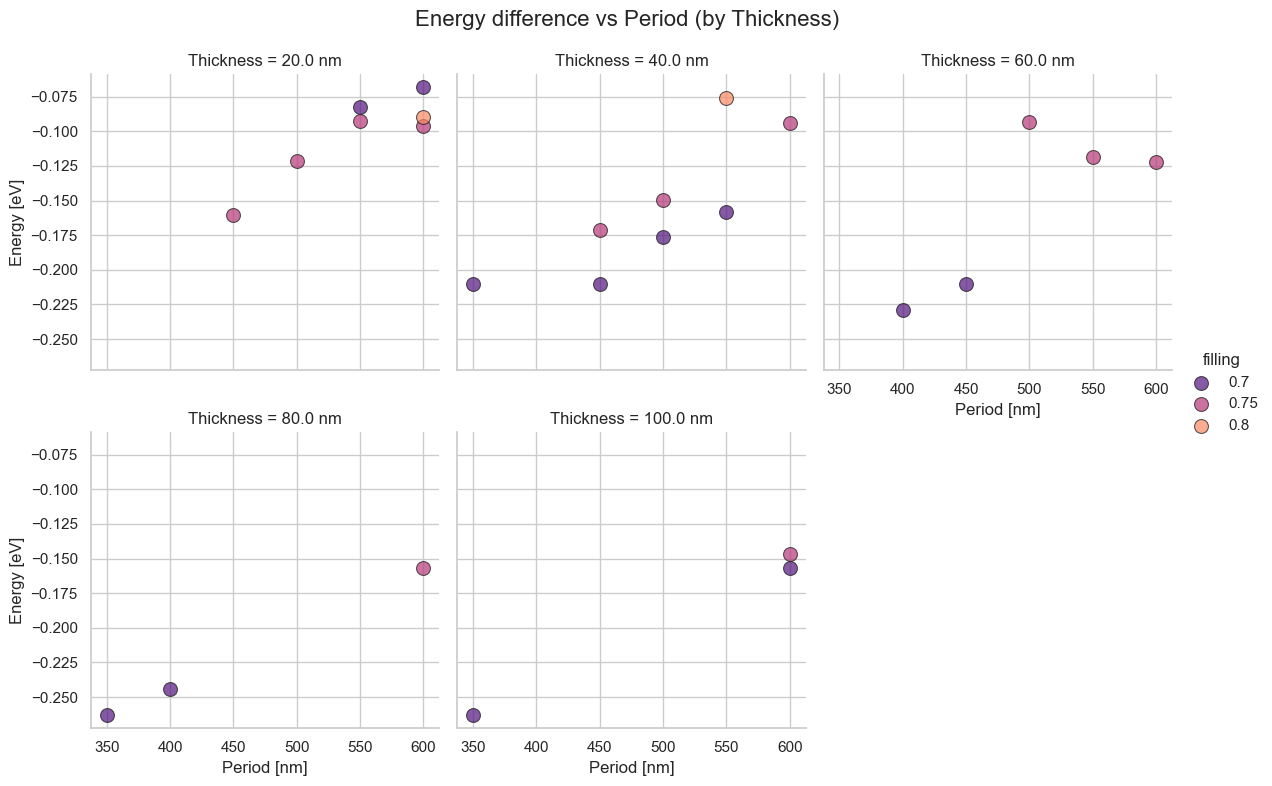

<Figure size 1500x1000 with 0 Axes>

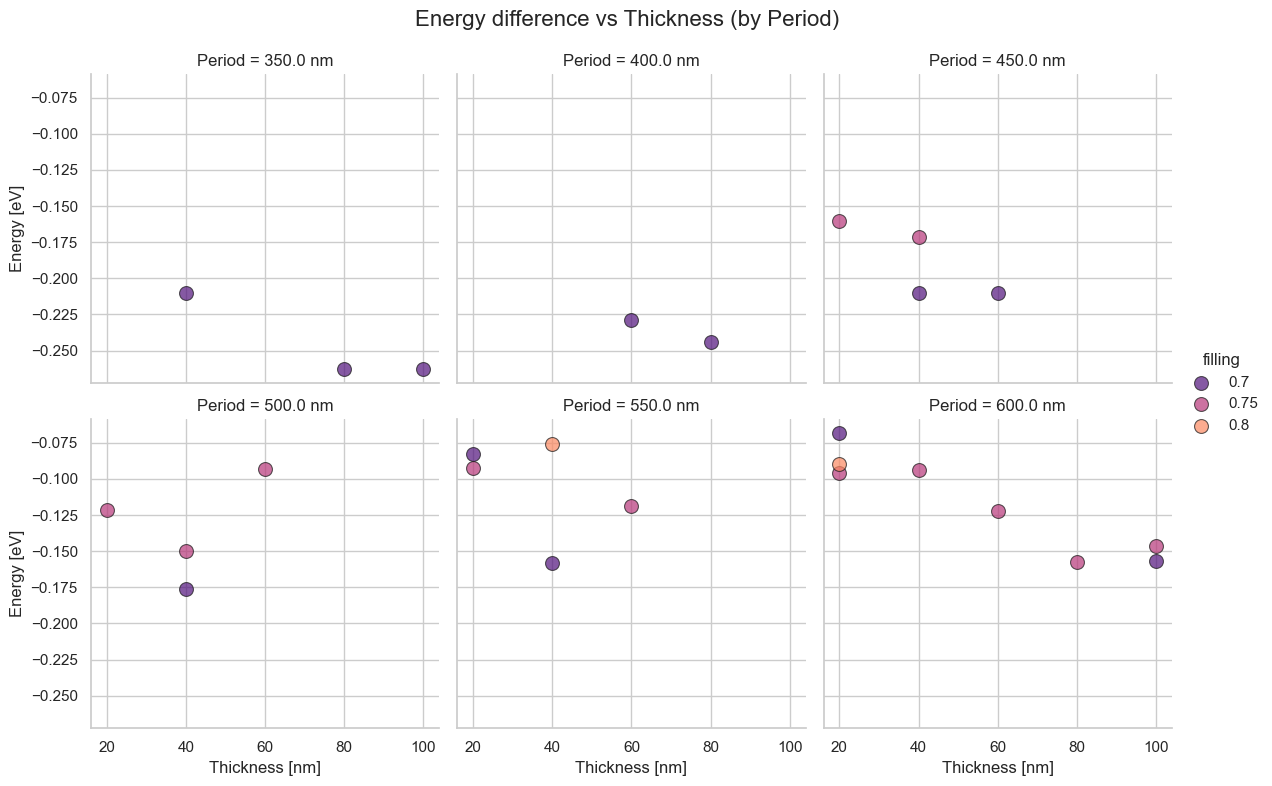

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the seaborn style
sns.set_theme(style="whitegrid")

# Create the figure for the 2D plots (Energy vs Period, with Thickness as separate plots)
fig1 = plt.figure(figsize=(15, 10))
g1 = sns.FacetGrid(
    data=df,
    col="thickness", 
    col_wrap=3, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g1.map_dataframe(
    sns.scatterplot, 
    x="period", 
    y="diff_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g1.set_axis_labels(p_lab, e_lab)
g1.set_titles(col_template="Thickness = {col_name} nm")
g1.add_legend()

# Display the Energy vs Period plot grid
plt.subplots_adjust(top=0.9)
g1.fig.suptitle('Energy difference vs Period (by Thickness)', fontsize=16)
plt.show()

# Create the figure for the 2D plots (Energy vs Thickness, with Period as separate plots)
fig2 = plt.figure(figsize=(15, 10))
g2 = sns.FacetGrid(
    data=df,
    col="period", 
    col_wrap=3, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g2.map_dataframe(
    sns.scatterplot, 
    x="thickness", 
    y="diff_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g2.set_axis_labels(t_lab, e_lab)
g2.set_titles(col_template="Period = {col_name} nm")
g2.add_legend()

# Display the Energy vs Thickness plot grid
plt.subplots_adjust(top=0.9)
g2.fig.suptitle('Energy difference vs Thickness (by Period)', fontsize=16)
plt.show()


In [10]:
print()